    support         itemsets
0  0.078502       (UHT-milk)
1  0.031042  (baking powder)
2  0.119548           (beef)
3  0.079785        (berries)
4  0.062083      (beverages)
       antecedents   consequents  antecedent support  consequent support  \
0       (UHT-milk)  (whole milk)            0.078502            0.458184   
1           (beef)  (whole milk)            0.119548            0.458184   
2   (bottled beer)  (whole milk)            0.158799            0.458184   
3  (bottled water)  (whole milk)            0.213699            0.458184   
4    (brown bread)  (whole milk)            0.135967            0.458184   

    support  confidence      lift  representativity  leverage  conviction  \
0  0.040534    0.516340  1.126928               1.0  0.004565    1.120242   
1  0.064135    0.536481  1.170886               1.0  0.009360    1.168919   
2  0.085428    0.537964  1.174124               1.0  0.012669    1.172672   
3  0.112365    0.525810  1.147597               1.0  0.014452

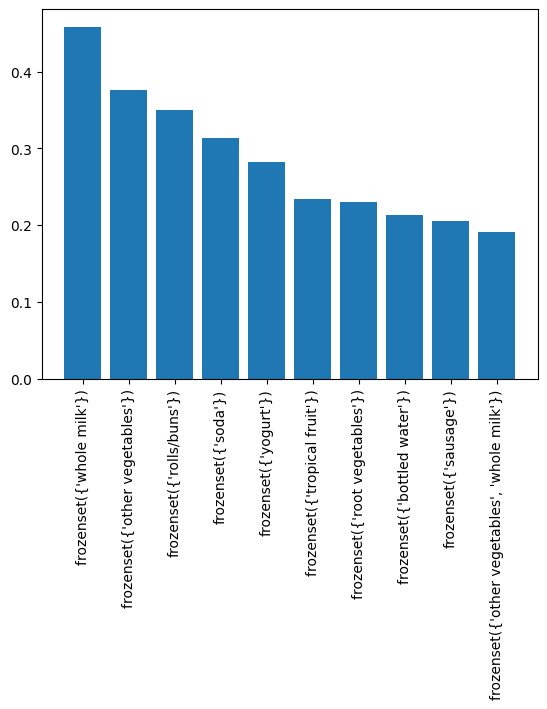

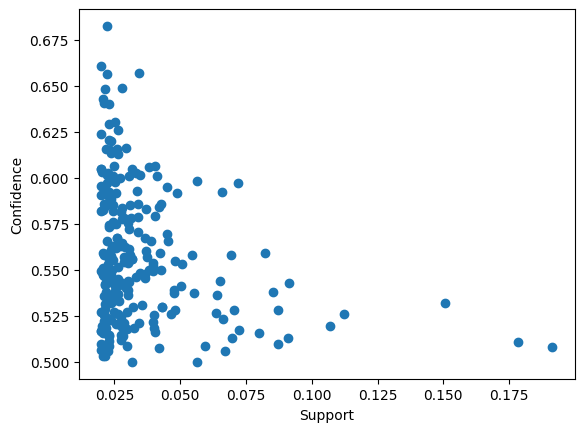

In [3]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt

df = pd.read_csv("Groceries_dataset.csv")

transactions = df.groupby('Member_number')['itemDescription'].apply(list)

import warnings
warnings.filterwarnings("ignore")


te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_data, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

strong_rules = rules[(rules['confidence'] > 0.6) & (rules['lift'] > 1)]

print(frequent_itemsets.head())
print(rules.head())
print(strong_rules)



top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), top_items['itemsets'], rotation=90)
plt.show()

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

s,aswin 24BAD014
[0.7470533  0.18435257 0.04682624 0.01764767 0.00412021]
[0.7470533  0.93140587 0.97823211 0.99587979 1.        ]


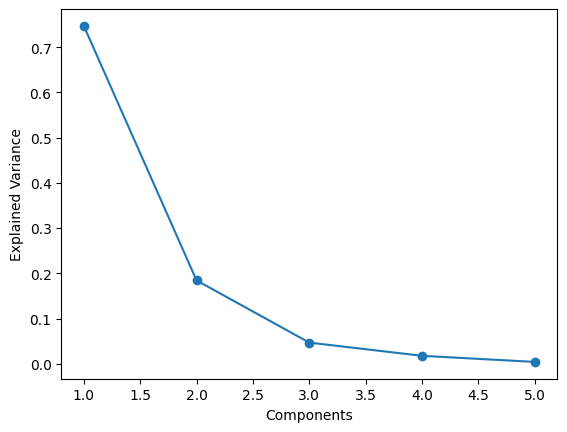

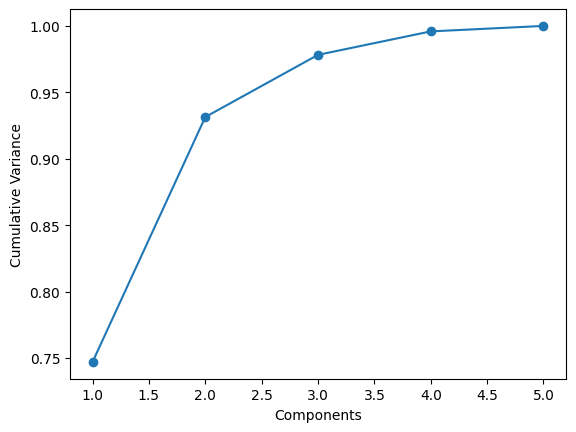

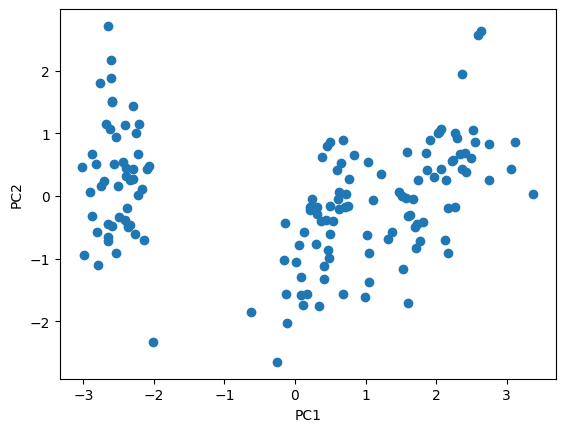

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("Iris.csv")

df = df.select_dtypes(include=['float64', 'int64'])

df = df.fillna(0)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_2 = PCA(n_components=2)
reduced_data = pca_2.fit_transform(scaled_data)
print("s,aswin 24BAD014")
print(explained_variance)
print(cumulative_variance)

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Components")
plt.ylabel("Explained Variance")
plt.show()

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

plt.scatter(reduced_data[:,0], reduced_data[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()